# Module 6 — Hypothesis Testing

**Statistics Deep Dive · Notebook 6 of 13**

A confidence interval says *"how large is the effect?"*. A hypothesis test answers a narrower question: *"could this result plausibly be nothing but chance?"* Tests are the most used — and most misused — tools in statistics. This module builds the logic from the ground up, so that you can use them without falling into the classic traps.

### 🎯 Learning goals
After this module you can …
1. formulate null and alternative hypotheses and explain the logic of a **p-value**,
2. run and interpret **one-sample, two-sample (Welch) and paired $t$-tests** and tests for **proportions**,
3. explain **type I / type II errors and power** and how they depend on $n$, effect size and $\alpha$,
4. build a **permutation test** from scratch for any statistic,
5. separate **statistical** from **practical significance** using effect sizes and confidence intervals,
6. list what a p-value is *not*.

### 🗺️ Contents
1. The logic of a test · 2. One-sample $t$-test · 3. Errors & power · 4. Two independent groups: Student vs. Welch · 5. Paired data · 6. Proportions · 7. Permutation tests · 8. Statistical vs. practical significance · 9. What a p-value is not · 10. Which test when? · 11. Exercises · 12. Takeaways

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

---
## 1. The logic of a significance test

A significance test is a **proof by contradiction, softened by probability**. It works like a court trial:

| Court | Statistics |
|---|---|
| presumption of innocence | **null hypothesis $H_0$**: "nothing is going on" (no effect, no difference, coin is fair) |
| prosecution's claim | **alternative $H_1$**: the effect you suspect |
| evidence | a **test statistic** computed from the data |
| "beyond reasonable doubt" | **significance level $\alpha$** (usually 0.05), fixed *before* looking at the data |
| verdict "guilty" | reject $H_0$ |
| verdict "not guilty" | fail to reject $H_0$ — which is **not** a proof of innocence! |

**The p-value** is the probability — *computed under the assumption that $H_0$ is true* — of obtaining a test statistic at least as extreme as the one observed:

$$p = P(\text{result at least this extreme} \mid H_0).$$

A small p-value means: *either* something rare happened, *or* $H_0$ is wrong. If $p \le \alpha$ we choose the second explanation.

**Example.** A coin lands heads 61 times in 100 flips. Is it fair? Under $H_0: p = 0.5$ the number of heads follows Binomial(100, 0.5) — this is the **null distribution**. "At least as extreme" (two-sided) means: at least 11 away from the expected 50, in either direction.

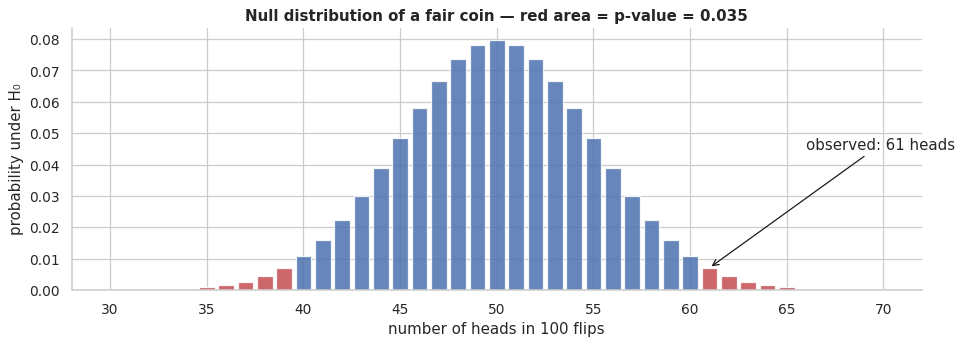

exact binomial test (scipy): p = 0.0352


In [2]:
n, k_obs = 100, 61
k = np.arange(n + 1); pmf = stats.binom.pmf(k, n, .5)
extreme = np.abs(k - n / 2) >= abs(k_obs - n / 2)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(k, pmf, color=[C[3] if e else C[0] for e in extreme], alpha=.85)
ax.annotate(f"observed: {k_obs} heads", xy=(k_obs, pmf[k_obs]), xytext=(66, .045), arrowprops=dict(arrowstyle="->", color="k"))
ax.set(xlim=(28, 72), xlabel="number of heads in 100 flips", ylabel="probability under H₀",
       title=f"Null distribution of a fair coin — red area = p-value = {pmf[extreme].sum():.3f}")
plt.tight_layout(); plt.show()
print(f"exact binomial test (scipy): p = {stats.binomtest(k_obs, n, 0.5).pvalue:.4f}")

**Reading the figure.** If the coin were fair, a result as lopsided as 61:39 (or worse) would occur in only about 3.5 % of all experiments. That is below $\alpha = 0.05$, so we reject $H_0$. Note what we did **not** compute: the probability that the coin is fair.

### The five steps of every test
1. State $H_0$ and $H_1$ (one- or two-sided) and fix $\alpha$ — *before* seeing the data.
2. Choose a test statistic whose distribution under $H_0$ is known (or can be simulated).
3. Compute the statistic from the data.
4. Compute the p-value from the null distribution.
5. Decide — and report the **effect size with a confidence interval**, not just "significant".

---
## 2. The one-sample $t$-test

**Question:** is the population mean equal to a reference value $\mu_0$? The test statistic measures how many standard errors the sample mean lies away from $\mu_0$:

$$t = \frac{\bar x - \mu_0}{s/\sqrt n} \;\sim\; t_{n-1} \quad\text{under } H_0.$$

**Assumptions:** independent observations; data roughly normal *or* $n$ large enough for the CLT (Module 4).

**Example.** A pizza service advertises "delivered in 30 minutes on average". A consumer magazine orders 20 pizzas.

mean = 32.80 min, s = 5.22, t by hand = 2.400
scipy: t = 2.400, two-sided p = 0.0268, 95 % CI for μ = [30.4, 35.2]


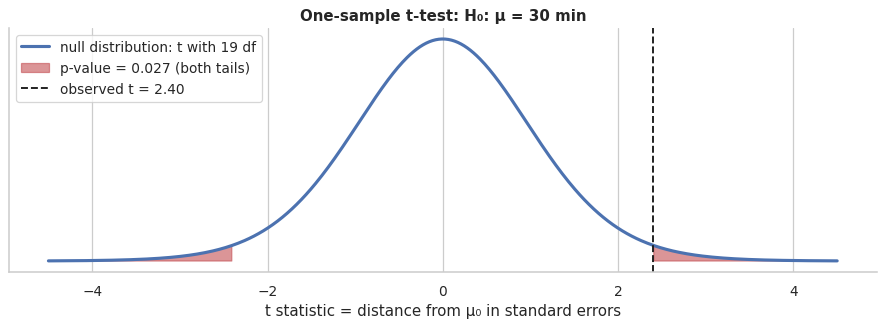

In [3]:
delivery = rng.normal(33, 6, 20)                    # 20 measured delivery times (min)
mu0 = 30
t_obs = (delivery.mean() - mu0) / (delivery.std(ddof=1) / np.sqrt(delivery.size))
res = stats.ttest_1samp(delivery, popmean=mu0)
print(f"mean = {delivery.mean():.2f} min, s = {delivery.std(ddof=1):.2f}, t by hand = {t_obs:.3f}")
print(f"scipy: t = {res.statistic:.3f}, two-sided p = {res.pvalue:.4f}, 95 % CI for μ = [{res.confidence_interval().low:.1f}, {res.confidence_interval().high:.1f}]")

x = np.linspace(-4.5, 4.5, 500); pdf = stats.t.pdf(x, df=delivery.size - 1)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(x, pdf, color=C[0], lw=2.5, label="null distribution: t with 19 df")
ax.fill_between(x, pdf, where=np.abs(x) >= abs(t_obs), color=C[3], alpha=.6, label=f"p-value = {res.pvalue:.3f} (both tails)")
ax.axvline(t_obs, color="k", ls="--", label=f"observed t = {t_obs:.2f}")
ax.set(xlabel="t statistic = distance from μ₀ in standard errors", yticks=[], title="One-sample t-test: H₀: μ = 30 min"); ax.legend()
plt.tight_layout(); plt.show()

**Test ⇄ confidence interval.** The two-sided test at level $\alpha$ rejects $H_0\!: \mu=\mu_0$ **exactly when** $\mu_0$ lies outside the $(1-\alpha)$ confidence interval. The interval is the more informative of the two: it lists *all* values of $\mu_0$ that the test would not reject.

**One-sided or two-sided?** Use a one-sided alternative (`alternative="greater"` / `"less"`) only if an effect in the other direction would be *irrelevant or impossible* — and decide this before seeing the data. Choosing the side after looking doubles your false-positive rate.

---
## 3. Two kinds of error — and power

| | $H_0$ is true | $H_0$ is false |
|---|---|---|
| **test rejects $H_0$** | **Type I error** (false alarm), probability $\alpha$ | correct — probability = **power** $= 1-\beta$ |
| **test does not reject** | correct | **Type II error** (missed effect), probability $\beta$ |

$\alpha$ is chosen by you. $\beta$ is a *consequence* of four things: the true **effect size**, the **noise** $\sigma$, the **sample size** $n$ and $\alpha$. The figure shows the sampling distribution of $\bar x$ under $H_0$ (μ = 100) and under one specific alternative (μ = 105), for a small and a larger study.

> 🤔 **Predict first:** when $n$ is quadrupled, what happens to the two curves — and to the orange area (β)?

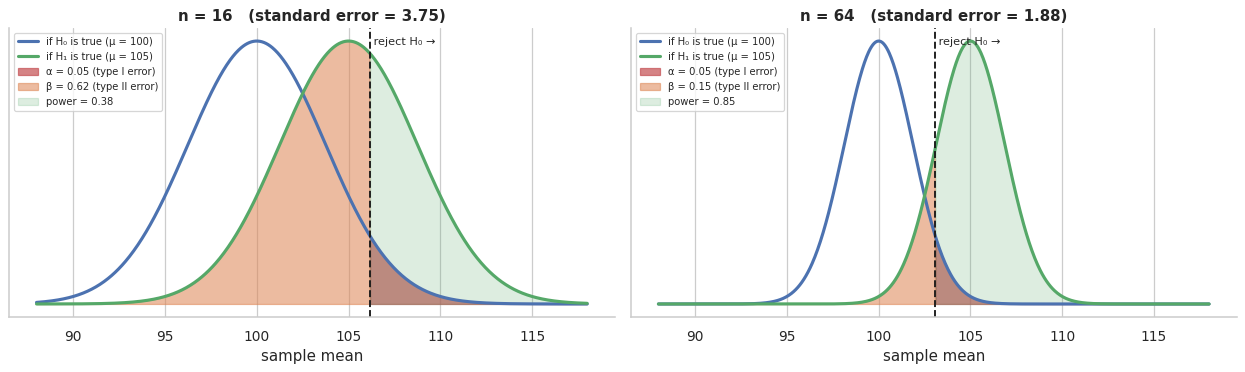

In [4]:
def draw_power(ax, n, mu0=100, mu1=105, sigma=15, alpha=.05):
    se = sigma / np.sqrt(n); crit = mu0 + stats.norm.ppf(1 - alpha) * se           # one-sided test, H1: mu > mu0
    x = np.linspace(88, 118, 800); f0, f1 = stats.norm.pdf(x, mu0, se), stats.norm.pdf(x, mu1, se)
    ax.plot(x, f0, color=C[0], lw=2.5, label="if H₀ is true (μ = 100)"); ax.plot(x, f1, color=C[2], lw=2.5, label="if H₁ is true (μ = 105)")
    ax.fill_between(x, f0, where=x >= crit, color=C[3], alpha=.7, label=f"α = {alpha:.2f} (type I error)")
    ax.fill_between(x, f1, where=x < crit, color=C[1], alpha=.55, label=f"β = {stats.norm.cdf(crit, mu1, se):.2f} (type II error)")
    ax.fill_between(x, f1, where=x >= crit, color=C[2], alpha=.2, label=f"power = {1 - stats.norm.cdf(crit, mu1, se):.2f}")
    ax.axvline(crit, color="k", ls="--"); ax.text(crit, ax.get_ylim()[1] * .97, " reject H₀ →", va="top", fontsize=9)
    ax.set(title=f"n = {n}   (standard error = {se:.2f})", xlabel="sample mean", yticks=[]); ax.legend(fontsize=8, loc="upper left")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
draw_power(axes[0], n=16); draw_power(axes[1], n=64)
plt.tight_layout(); plt.show()

**Reading the figure.** Larger $n$ makes both sampling distributions narrower, so they overlap less: β shrinks from about 0.62 to 0.15 while α stays at 5 %. The same happens if the true effect is larger or the noise smaller. A study with low power is a bad study **even before it starts**: it will probably miss a real effect, and if it does find "significance", the estimated effect is likely exaggerated. Planning sample sizes for a target power (typically 80–90 %) is the topic of Module 8.

### 3.1 How p-values behave over many studies
We simulate 10,000 two-group experiments ($n=30$ per group) — once with no true effect, once with a true difference of half a standard deviation.

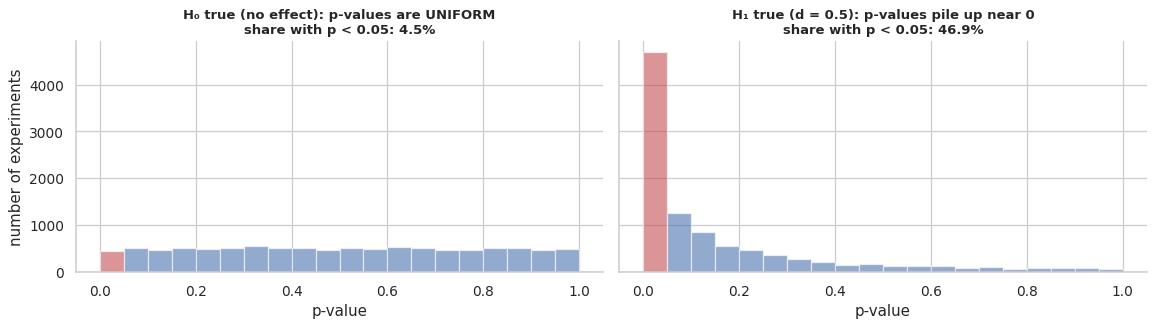

In [5]:
R, n = 10_000, 30
p_null = stats.ttest_ind(rng.normal(0, 1, (R, n)), rng.normal(0, 1, (R, n)), axis=1).pvalue
p_alt = stats.ttest_ind(rng.normal(.5, 1, (R, n)), rng.normal(0, 1, (R, n)), axis=1).pvalue
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, p, title in zip(axes, [p_null, p_alt], ["H₀ true (no effect): p-values are UNIFORM", "H₁ true (d = 0.5): p-values pile up near 0"]):
    counts, edges, patches = ax.hist(p, bins=np.arange(0, 1.05, .05), color=C[0], alpha=.6, edgecolor="white")
    patches[0].set_facecolor(C[3])
    ax.set(title=f"{title}\nshare with p < 0.05: {(p < .05).mean():.1%}", xlabel="p-value"); ax.title.set_fontsize(10.5)
axes[0].set_ylabel("number of experiments")
plt.tight_layout(); plt.show()

**Reading the figure.** *Left:* when $H_0$ is true every p-value is equally likely, so exactly a fraction $\alpha$ of all experiments is "significant" by pure chance — that **is** the type I error rate. *Right:* with a real, medium-sized effect and $n=30$ per group the power is only about 48 %: more than half of such studies would miss the effect.

---
## 4. Comparing two independent groups — Student vs. Welch

$$t = \frac{\bar x_1 - \bar x_2}{\operatorname{SE}(\bar x_1-\bar x_2)}$$

* **Student's $t$-test** pools the two variances — it *assumes* $\sigma_1=\sigma_2$.
* **Welch's $t$-test** uses $\sqrt{s_1^2/n_1+s_2^2/n_2}$ with adjusted degrees of freedom — no such assumption.

Does the difference matter? We check the actual false-positive rate (both group means are equal, so every rejection is a false alarm) in four situations.

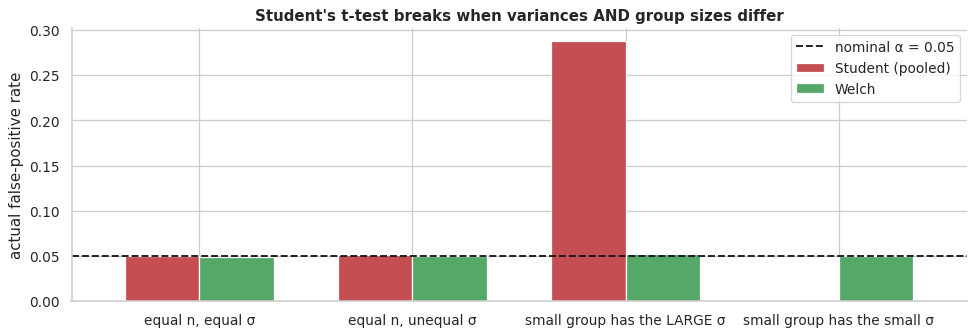

In [6]:
def false_positive_rate(n1, s1, n2, s2, equal_var, R=20_000):
    a, b = rng.normal(0, s1, (R, n1)), rng.normal(0, s2, (R, n2))
    return (stats.ttest_ind(a, b, axis=1, equal_var=equal_var).pvalue < .05).mean()

scenarios = {"equal n, equal σ": (30, 1, 30, 1), "equal n, unequal σ": (30, 1, 30, 3),
             "small group has the LARGE σ": (10, 3, 50, 1), "small group has the small σ": (10, 1, 50, 3)}
fpr = pd.DataFrame({name: {"Student (pooled)": false_positive_rate(*args, True), "Welch": false_positive_rate(*args, False)}
                    for name, args in scenarios.items()}).T
ax = fpr.plot.bar(figsize=(11, 3.9), color=[C[3], C[2]], rot=0, width=.7)
ax.axhline(.05, color="k", ls="--", label="nominal α = 0.05"); ax.set(ylabel="actual false-positive rate", title="Student's t-test breaks when variances AND group sizes differ"); ax.legend()
plt.tight_layout(); plt.show()

**Reading the figure.** Welch keeps its promise (≈ 5 %) everywhere. Student's test produces false alarms in almost 30 % of all tests when the small group is the noisy one, and is far too conservative in the opposite case. **Recommendation: always use Welch** (`equal_var=False`); you lose practically nothing when variances happen to be equal. Do *not* run a variance pre-test to choose between them — that two-stage procedure has worse error properties than Welch alone.

---
## 5. Paired data — let every unit be its own control

If the same units are measured twice (before/after, left/right, twin A/twin B), the observations are **not independent**. The paired $t$-test simply runs a one-sample test on the **differences** $d_i$:

$$t = \frac{\bar d}{s_d/\sqrt n}.$$

Pairing removes the between-subject variability from the comparison — often a dramatic gain in power.

WRONG  (independent samples): p = 0.640
RIGHT  (paired)             : p = 0.00205   mean difference = -7.1 ms


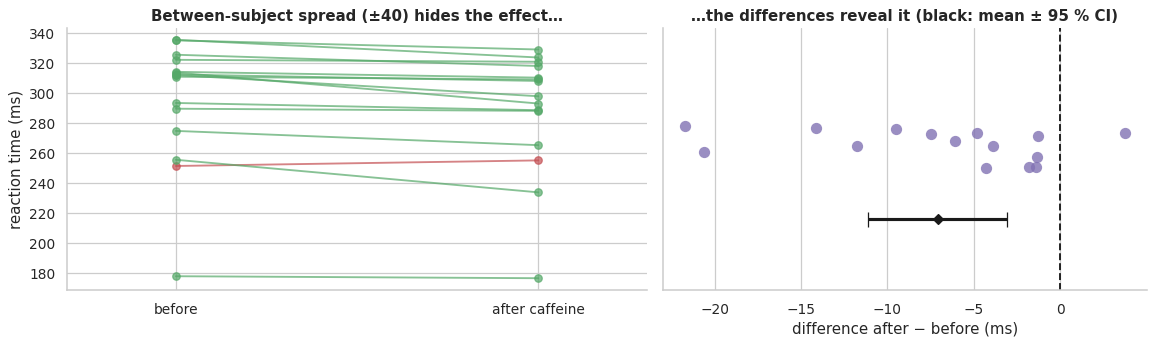

In [7]:
subject_level = rng.normal(300, 40, 15)                       # people differ a lot in baseline reaction time (ms)
before = subject_level + rng.normal(0, 8, 15)
after = subject_level - 12 + rng.normal(0, 8, 15)             # true effect of caffeine: −12 ms
d = after - before
print(f"WRONG  (independent samples): p = {stats.ttest_ind(after, before, equal_var=False).pvalue:.3f}")
print(f"RIGHT  (paired)             : p = {stats.ttest_rel(after, before).pvalue:.5f}   mean difference = {d.mean():.1f} ms")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1.2, 1]})
for b, a in zip(before, after):
    a1.plot([0, 1], [b, a], "o-", color=C[2] if a < b else C[3], alpha=.7)
a1.set(xticks=[0, 1], xticklabels=["before", "after caffeine"], xlim=(-.3, 1.3), ylabel="reaction time (ms)",
       title="Between-subject spread (±40) hides the effect…")
sns.stripplot(x=d, ax=a2, color=C[4], size=9, alpha=.8); a2.axvline(0, color="k", ls="--")
lo, hi = stats.t.interval(.95, d.size - 1, loc=d.mean(), scale=stats.sem(d))
a2.errorbar([d.mean()], [.3], xerr=[[d.mean() - lo], [hi - d.mean()]], fmt="D", color="k", capsize=6, lw=2.5)
a2.set(ylim=(.6, -.5), xlabel="difference after − before (ms)", title="…the differences reveal it (black: mean ± 95 % CI)")
plt.tight_layout(); plt.show()

---
## 6. Tests for proportions

For a binary outcome (converted / not, cured / not) we compare proportions. With large samples the **two-proportion $z$-test** uses the pooled proportion $\hat p$ under $H_0: p_1=p_2$:

$$z = \frac{\hat p_1 - \hat p_2}{\sqrt{\hat p(1-\hat p)\left(\frac{1}{n_1}+\frac{1}{n_2}\right)}}, \qquad \hat p = \frac{k_1+k_2}{n_1+n_2}.$$

Rule of thumb: at least ~10 successes *and* 10 failures per group. For one proportion against a reference value use the exact `stats.binomtest` (section 1); for small 2×2 tables use Fisher's exact test (Module 7). The squared $z$ statistic equals the $\chi^2$ statistic of the 2×2 table — they are the same test.

In [8]:
k = np.array([48, 72]); n = np.array([1000, 1000])          # sign-ups: old vs. new landing page
z, p = proportions_ztest(k, n)
print(f"conversion: {k[0] / n[0]:.1%} vs {k[1] / n[1]:.1%}  ->  z = {z:.2f}, p = {p:.4f}")
print(f"chi-square test of the 2x2 table: chi2 = {stats.chi2_contingency([k, n - k], correction=False)[0]:.2f} = z² = {z ** 2:.2f}")

conversion: 4.8% vs 7.2%  ->  z = -2.26, p = 0.0238
chi-square test of the 2x2 table: chi2 = 5.11 = z² = 5.11


---
## 7. Permutation tests — the null distribution by brute force

**Idea:** if the group label has *no effect* ($H_0$), the labels are arbitrary — shuffling them produces data sets that were just as likely as the observed one. Shuffle many times, recompute the statistic each time → an empirical **null distribution**. The p-value is the share of shuffles that are at least as extreme as the real data.

**Why this is great:** works for *any* statistic (difference in medians, trimmed means, ratios, …), needs no normality, and is exactly valid in randomised experiments. **Limits:** it tests the *sharp* null "the two distributions are identical"; computationally heavier.

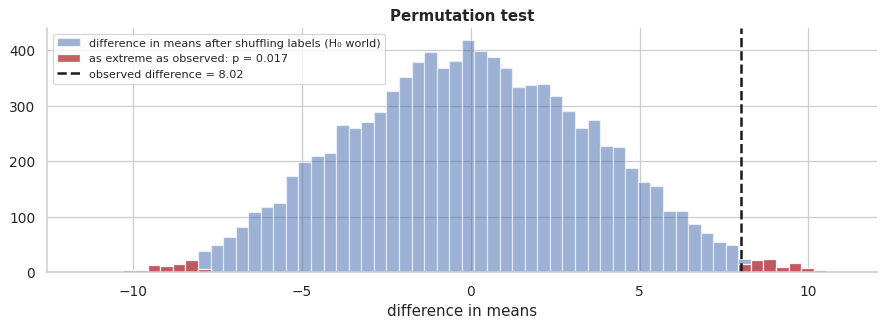

Welch t-test for comparison: p = 0.023


In [9]:
g = np.random.default_rng(8)
group_a = g.exponential(10, 12) + 8           # skewed data, small samples: t-test assumptions doubtful
group_b = g.exponential(10, 14)
observed = group_a.mean() - group_b.mean()
pooled = np.concatenate([group_a, group_b])

perm = np.empty(10_000)
for i in range(perm.size):
    shuffled = rng.permutation(pooled)                                        # re-deal the group labels at random
    perm[i] = shuffled[:group_a.size].mean() - shuffled[group_a.size:].mean()
p_perm = (np.abs(perm) >= abs(observed)).mean()

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.hist(perm, bins=60, color=C[0], alpha=.55, label="difference in means after shuffling labels (H₀ world)")
ax.hist(perm[np.abs(perm) >= abs(observed)], bins=60, range=(perm.min(), perm.max()), color=C[3], alpha=.9, label=f"as extreme as observed: p = {p_perm:.3f}")
ax.axvline(observed, color="k", ls="--", lw=2, label=f"observed difference = {observed:.2f}")
ax.set(xlabel="difference in means", title="Permutation test"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"Welch t-test for comparison: p = {stats.ttest_ind(group_a, group_b, equal_var=False).pvalue:.3f}")

---
## 8. Statistical vs. practical significance

A p-value mixes two things: the **size of the effect** and the **amount of data**. With enough data *any* non-zero difference becomes "significant", however irrelevant. Therefore always report a standardised or a natural **effect size**:

$$\text{Cohen's } d = \frac{\bar x_1-\bar x_2}{s_{pooled}} \qquad (\approx 0.2\ \text{small},\ 0.5\ \text{medium},\ 0.8\ \text{large — rough conventions, not laws})$$

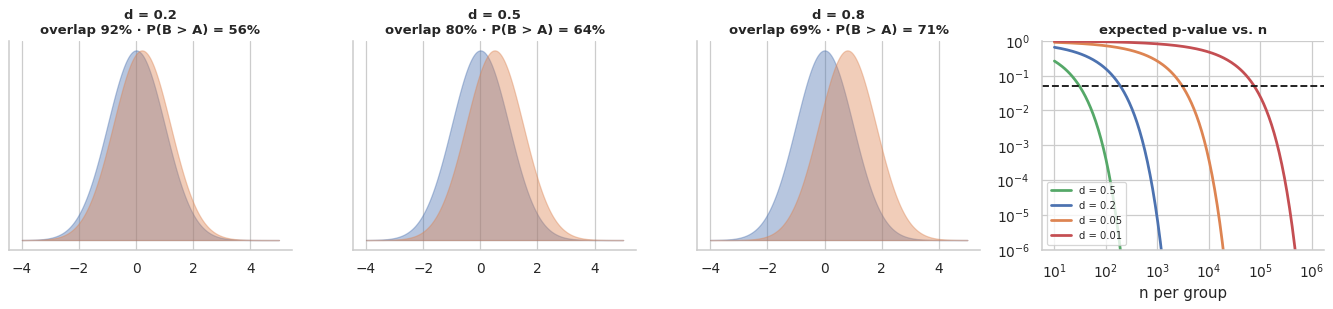

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
x = np.linspace(-4, 5, 500)
for ax, d in zip(axes[:3], [.2, .5, .8]):
    ax.fill_between(x, stats.norm.pdf(x), color=C[0], alpha=.4); ax.fill_between(x, stats.norm.pdf(x, d), color=C[1], alpha=.4)
    ax.set(yticks=[], title=f"d = {d}\noverlap {2 * stats.norm.cdf(-d / 2):.0%} · P(B > A) = {stats.norm.cdf(d / np.sqrt(2)):.0%}"); ax.title.set_fontsize(10.5)
n = np.logspace(1, 6, 200)
for d, col in zip([.5, .2, .05, .01], [C[2], C[0], C[1], C[3]]):
    axes[3].plot(n, 2 * stats.norm.sf(d * np.sqrt(n / 2)), color=col, lw=2.2, label=f"d = {d}")
axes[3].axhline(.05, color="k", ls="--"); axes[3].set(xscale="log", yscale="log", ylim=(1e-6, 1), xlabel="n per group", title="expected p-value vs. n"); axes[3].title.set_fontsize(10.5); axes[3].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading the figure.** Even a "large" effect of $d=0.8$ leaves two thirds of the distributions overlapping — group differences say little about individuals. *Right panel:* a negligible effect of $d = 0.01$ becomes "highly significant" once $n$ approaches a million per group — everyday business for web-scale A/B tests. **Significance tells you an effect is probably not zero; only the effect size and its CI tell you whether it matters.**

---
## 9. What a p-value is *not*

| Misconception | Reality |
|---|---|
| "p = 0.03 means there is a 3 % chance that $H_0$ is true." | p is computed *assuming* $H_0$ is true. $P(\text{data}\mid H_0) \neq P(H_0\mid\text{data})$ — that needs Bayes' theorem (Modules 2 and 12). |
| "p = 0.03 means a 3 % chance the result is due to chance." | Same error in different words. |
| "p > 0.05, so there is no effect." | Absence of evidence ≠ evidence of absence. Look at the CI: is it narrow around 0, or just wide? |
| "p = 0.001 means a big effect." | It may be a tiny effect measured on a huge sample. |
| "p = 0.049 and p = 0.051 are fundamentally different." | 0.05 is a convention. Report exact p-values, effect sizes and intervals. |
| "If I test often enough, I will find something." | True — and that is the problem: see multiple testing and p-hacking in Module 8. |

---
## 10. Which test when?

| Question | Outcome | Standard test | Assumption-lean alternative |
|---|---|---|---|
| one mean vs. reference | numeric | one-sample $t$ | Wilcoxon signed-rank, bootstrap |
| two independent groups | numeric | **Welch $t$** | Mann–Whitney $U$, permutation test |
| two paired measurements | numeric | paired $t$ | Wilcoxon signed-rank, sign test |
| three or more groups | numeric | ANOVA (Module 7) | Kruskal–Wallis |
| one proportion vs. reference | binary | exact binomial test | — |
| two proportions | binary | two-proportion $z$ / $\chi^2$ | Fisher's exact test |
| association of two categorical variables | categorical | $\chi^2$ test of independence (Module 7) | Fisher's exact / permutation |
| association of two numeric variables | numeric | correlation / regression $t$-test (Module 9) | Spearman, permutation |

---
## 11. Exercises — real-world use cases
Each exercise is self-contained. Run the data cell, then work in the empty cell below it.

### ✍️ Exercise 6.1 — *One-sample t-test*: Is the filling machine under-filling? (Food production / legal metrology)

A dairy fills bottles labelled **500 ml**. The quality team measures 25 randomly selected bottles from today's production. Under-filling risks fines from the weights-and-measures authority; over-filling gives product away.

**Tasks**
1. State $H_0$ and $H_1$ for a two-sided test and compute $t$ and $p$ by hand and with `stats.ttest_1samp`.
2. Give the 95 % CI for the mean fill volume. How does it relate to the test decision?
3. The authority only cares about *under*-filling. Run the appropriate one-sided test.
4. Check the normality assumption (Q–Q plot or Shapiro–Wilk).
5. What do you recommend to the production manager?

In [11]:
g = np.random.default_rng(601)
fill = pd.Series(g.normal(498.6, 2.8, 25).round(1), name="fill_ml")
print(fill.values)

[500.8 498.5 500.2 499.7 498.5 494.1 501.9 499.9 496.7 496.4 502.7 503.1
 498.8 499.5 499.8 496.1 497.6 498.1 500.9 494.9 496.3 499.2 495.6 497.1
 495.5]


In [12]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/06_hypothesis_testing_solutions.ipynb`.

### ✍️ Exercise 6.2 — *Welch two-sample t-test*: Does the new drug lower blood pressure? (Clinical trial)

In a randomised, double-blind trial, patients received a new antihypertensive drug or a placebo for 8 weeks. The outcome is the **change in systolic blood pressure** (mmHg; negative = improvement). Clinicians regard a reduction of at least 5 mmHg relative to placebo as *clinically relevant*.

**Tasks**
1. Visualise both groups.
2. Test $H_0$: equal mean change, with Welch's test. Report the difference with 95 % CI.
3. Compute Cohen's $d$.
4. Is the effect statistically significant? Is it clinically relevant? Are these the same question?

In [13]:
g = np.random.default_rng(610)
bp = pd.DataFrame({"group": ["placebo"] * 42 + ["drug"] * 45,
                   "change_mmHg": np.concatenate([g.normal(-2.0, 11, 42), g.normal(-8.5, 13, 45)]).round(1)})
bp.groupby("group").change_mmHg.agg(["count", "mean", "std"]).round(2)

,count,mean,std
group,,,
drug,45,-7.96,14.46
placebo,42,-1.21,9.25


In [14]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/06_hypothesis_testing_solutions.ipynb`.

### ✍️ Exercise 6.3 — *Paired t-test*: Does the fuel additive pay off? (Fleet management)

A logistics company tests a fuel additive (cost: **€150 per van per year**). Each of 12 vans drives one month without and one month with the additive (order randomised). Vans differ strongly in consumption (route, load, driver). Each van drives about 40,000 km per year; diesel costs €1.60 per litre.

**Tasks**
1. Run the (wrong) independent-samples test and the (correct) paired test. Explain the difference.
2. Plot the paired data.
3. Give a 95 % CI for the mean saving in l/100 km and convert it to € per van per year.
4. Does the additive pay off?

In [15]:
g = np.random.default_rng(626)
van_level = g.normal(9.8, 1.6, 12)
fuel = pd.DataFrame({"van": [f"V{i + 1:02d}" for i in range(12)],
                     "without": (van_level + g.normal(0, .25, 12)).round(2),
                     "with_additive": (van_level - .35 + g.normal(0, .25, 12)).round(2)})
fuel

,van,without,with_additive
0,V01,11.81,11.22
1,V02,9.74,9.15
2,V03,8.74,8.24
3,V04,8.82,8.60
4,V05,12.14,11.77
5,V06,10.38,9.95
6,V07,9.41,9.73
7,V08,8.47,8.19
8,V09,9.54,9.05
9,V10,11.62,11.17


In [16]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/06_hypothesis_testing_solutions.ipynb`.

### ✍️ Exercise 6.4 — *Two-proportion z-test*: Did the redesigned checkout convert better? (E-commerce A/B test)

Visitors were randomly assigned to the current checkout (A) or a redesigned one (B).

**Tasks**
1. Compute both conversion rates, the absolute difference (percentage points) and the relative lift.
2. Compute the $z$ statistic by hand (pooled SE) and verify with `proportions_ztest`.
3. Give a 95 % CI for the absolute difference (unpooled SE).
4. Verify numerically that $z^2$ equals the $\chi^2$ statistic of the 2×2 table.
5. The redesign is only worth rolling out if it brings at least +0.2 percentage points. What is your recommendation?

In [17]:
visitors = np.array([15_230, 15_118])      # A, B
orders = np.array([594, 671])

In [18]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/06_hypothesis_testing_solutions.ipynb`.

### ✍️ Exercise 6.5 — *Permutation test*: A new physiotherapy protocol with a tiny sample (Rehabilitation medicine)

A clinic pilots a new rehabilitation protocol after knee surgery. Outcome: days until the patient can walk stairs without aid. Samples are small and recovery times are right-skewed, so you do not want to lean on the $t$-distribution.

**Tasks**
1. Compute the observed difference in **means** and in **medians**.
2. Write a permutation test (10,000 shuffles) for the difference in means (two-sided).
3. Cross-check with `stats.permutation_test` and with Welch's $t$-test.
4. Repeat for the difference in medians. What do you conclude, and what would you advise the clinic?

In [19]:
g = np.random.default_rng(626)
standard = np.round(g.lognormal(np.log(30), .45, 10))
new = np.round(g.lognormal(np.log(21), .45, 9))
print("standard:", standard, "\nnew     :", new)

standard: [51. 30. 22. 22. 56. 33. 31. 20. 26. 52.] 
new     : [25. 37. 26. 19. 21. 26. 25. 31.  8.]


In [20]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/06_hypothesis_testing_solutions.ipynb`.

---
## 12. 🔑 Key takeaways

* A test asks: *how surprising is my data if $H_0$ were true?* The p-value is $P(\text{data this extreme}\mid H_0)$ — **not** $P(H_0\mid \text{data})$.
* Fix hypotheses, sidedness and $\alpha$ **before** looking at the data.
* **Type I error** rate = $\alpha$ (your choice). **Power** $= 1-\beta$ depends on effect size, noise, $n$ and $\alpha$ — plan for it.
* Two independent groups → **Welch**. Same units measured twice → **paired** test. Binary outcomes → proportion tests.
* **Permutation tests** build the null distribution by shuffling labels; they work for any statistic.
* A two-sided test at level $\alpha$ and a $(1-\alpha)$ confidence interval always agree — and the interval tells you more.
* **Significant ≠ important.** Always report the effect size with its interval and judge it against a practical threshold.

### Cheat sheet
| Task | Code |
|---|---|
| one-sample $t$ | `stats.ttest_1samp(x, popmean=mu0, alternative="two-sided")` |
| Welch two-sample $t$ | `stats.ttest_ind(a, b, equal_var=False)` → `.pvalue`, `.confidence_interval()` |
| paired $t$ | `stats.ttest_rel(after, before)` |
| exact test for one proportion | `stats.binomtest(k, n, p0)` |
| two proportions | `proportions_ztest([k1, k2], [n1, n2])` |
| permutation test | `stats.permutation_test((a, b), statistic, n_resamples=9999)` |
| normality check | `stats.shapiro(x)`, `stats.probplot(x, plot=ax)` |

**Next:** Module 7 — more than two groups and categorical data: ANOVA, rank-based tests and $\chi^2$ tests.